<a href="https://colab.research.google.com/github/vicayumi/Calculo_Numerico/blob/main/Atividade2_CN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Atividade feita por Victoria Ayumi Kose e Maria Luiza Balbo**

---



**1) Objetivos**

Investigar a relação entre estabilidade numérica, passo de tempo e ocorrência de
overflow em uma simulação simplificada de dinâmica dos fluidos computacional.
Ao final da atividade, o aluno deverá ser capaz de:

• explicar o overflow em números de ponto flutuante;

• distinguir instabilidade numérica de overflow;

• calcular o limite de estabilidade do método utilizado;

• detectar falhas numéricas em Python;

• avaliar os efeitos do tipo numérico.

**2) Descrição do problema - Elaborado para o depois**

Uma equipe está simulando o movimento de um fluido entre duas placas paralelas, separadas
por uma distância de H = 0,01 m.
Inicialmente, o fluido está parado. No instante inicial, a placa localizada em y = 0 começa
a se mover com velocidade constante U = 1 m/s, enquanto a placa em y = H permanece fixa.
A viscosidade transmite gradualmente o movimento da placa para o interior do fluido.
Contudo, em algumas configurações numéricas, o programa calcula velocidades crescentes e
não físicas, até que ocorra overflow.

Desafio: reproduzir a falha, identificar sua causa e testar uma configuração numericamente
estável.

**3) Fundamentação teórica**

**3.1) Representação em ponto flutuante e overflow**

Os valores de velocidade são armazenados em números de ponto flutuante, cuja representação pode ser expressa, de forma simplificada, por:

$$
x = (-1)^s \, m \, 2^e
$$

onde:

- $s$ representa o **sinal**;
- $m$ representa o **significando**;
- $e$ representa o **expoente**.

Como o número de bits é limitado, existe um maior valor finito representável em cada tipo numérico.

| Tipo numérico | Maior valor finito aproximado |
|---|---:|
| `float32` | $3,4 \times 10^{38}$ |
| `float64` | $1,8 \times 10^{308}$ |


O overflow ocorre quando o resultado de uma operação ultrapassa a faixa de valores que pode ser representada pelo tipo numérico utilizado.

Em operações de ponto flutuante no NumPy, isso pode produzir valores infinitos (`inf`) e gerar avisos de execução (*RuntimeWarning*).

Também é possível configurar o programa para interromper o cálculo quando um overflow for detectado.

> **Atenção:** instabilidade numérica e overflow não são sinônimos.
A **instabilidade numérica** pode amplificar perturbações e erros durante os cálculos. Já o **overflow** ocorre quando alguma operação ultrapassa a capacidade de representação do tipo numérico.
Portanto, uma solução pode estar **incorreta muito antes de apresentar overflow**.

**3.2) Modelo físico**

Considere um **fluido newtoniano**, com viscosidade constante, escoamento unidirecional, ausência de gradiente de pressão e ausência de variação ao longo das placas.

Nessas condições, a equação da velocidade é dada por:

$$
\frac{\partial u}{\partial t}
=
\nu
\frac{\partial^2 u}{\partial y^2}
$$

onde:

- $u(y,t)$ é a **velocidade paralela às placas**, em m/s;
- $y$ é a **posição transversal**, em m;
- $t$ é o **tempo**, em s;
- $\nu$ é a **viscosidade cinemática**, em m²/s.

Para $t > 0$, as condições de contorno são:

$$
u(0,t) = U
$$

$$
u(H,t) = 0
$$

Ou seja, a velocidade na placa inferior é $U$, enquanto a velocidade na placa superior é igual a zero.

No interior do domínio, a condição inicial é:

$$
u(y,0) = 0,
\qquad 0 < y < H
$$

Isso significa que, inicialmente, o fluido encontra-se em **repouso no interior do domínio**.

**3.3) Discretização**

Utilizando o método de **Euler explícito no tempo** e **diferenças finitas centrais no espaço**, a equação pode ser discretizada como:

$$
\frac{u_i^{n+1}-u_i^n}{\Delta t}
=
\nu
\frac{u_{i+1}^n-2u_i^n+u_{i-1}^n}{\Delta y^2}
$$

Isolando a velocidade no próximo instante de tempo:

$$
u_i^{n+1}
=
u_i^n
+
r
\left(
u_{i+1}^n
-
2u_i^n
+
u_{i-1}^n
\right)
$$

onde:

$$
r=\frac{\nu\Delta t}{\Delta y^2}
$$

O parâmetro $r$ relaciona a **viscosidade cinemática**, o **passo de tempo** e o **espaçamento da malha**.

- $i$ identifica a **posição na malha espacial**;
- $n$ identifica o **instante de tempo**;
- $u_i^n$ representa a velocidade na posição $i$ no instante $n$;
- $\Delta y$ representa o **espaçamento entre os pontos da malha**;
- $\Delta t$ representa o **passo de tempo**;
- $\nu$ representa a **viscosidade cinemática**;
- $r$ é o **número adimensional utilizado na discretização**.

A velocidade em cada ponto interno da malha é atualizada utilizando os valores dos dois pontos vizinhos:

$$
u_i^{n+1}
=
u_i^n
+
r
\left[
u_{i+1}^n
-
2u_i^n
+
u_{i-1}^n
\right]
$$

Assim, o método permite calcular a evolução da velocidade ao longo do tempo a partir das condições iniciais e das condições de contorno estabelecidas no modelo físico.

**3.4) Condição de estabilidade**

Para o esquema de difusão unidimensional utilizado nesta atividade, a condição de estabilidade é:

$$
r \leq \frac{1}{2}
$$

Como:

$$
r = \frac{\nu \Delta t}{\Delta y^2}
$$

podemos obter a seguinte restrição para o passo de tempo:

$$
\Delta t \leq \frac{\Delta y^2}{2\nu}
$$

Reorganizando a equação de atualização da velocidade:

$$
u_i^{n+1}
=
r u_{i-1}^n
+
(1-2r)u_i^n
+
r u_{i+1}^n
$$

Quando:

$$
0 \leq r \leq \frac{1}{2}
$$

os coeficientes da equação são **não negativos** e sua soma é igual a 1:

$$
r + (1-2r) + r = 1
$$

Dessa forma, a atualização da velocidade pode ser interpretada como uma **média ponderada** dos valores vizinhos.

Quando:

$$
r > \frac{1}{2}
$$

o coeficiente central:

$$
1-2r
$$

torna-se **negativo**.

Isso pode provocar oscilações numéricas que podem crescer ao longo das iterações. Em situações mais extremas, essas oscilações podem gerar valores muito grandes e eventualmente levar a **overflow**.

> **Observação:** o limite $r \leq 1/2$ é específico do esquema numérico utilizado nesta atividade. Outros métodos de discretização e outras equações de CFD podem apresentar condições de estabilidade diferentes.

### Resumo

| Condição | Comportamento |
|---|---|
| $0 \leq r \leq 1/2$ | Esquema estável |
| $r > 1/2$ | Esquema instável |
| $\Delta t \leq \frac{\Delta y^2}{2\nu}$ | Condição de estabilidade satisfeita |
| $\Delta t > \frac{\Delta y^2}{2\nu}$ | Condição de estabilidade violada |

**4) Dados da simulação**

Os parâmetros utilizados na simulação são apresentados na tabela abaixo:

| Parâmetro | Símbolo | Valor |
|---|:---:|---:|
| Distância entre as placas | $H$ | $0,01$ m |
| Viscosidade cinemática | $\nu$ | $10^{-4}$ m²/s |
| Número de pontos, incluindo as paredes | $N$ | $21$ |
| Espaçamento da malha | $\Delta y$ | $0,0005$ m |
| Velocidade da placa móvel | $U$ | $1$ m/s |
| Velocidade da placa fixa | — | $0$ m/s |

O espaçamento entre os pontos da malha é calculado por:

$$
\Delta y = \frac{H}{21-1}
$$

Substituindo os valores:

$$
\Delta y = \frac{0,01}{20}
$$

$$
\boxed{\Delta y = 0,0005\text{ m}}
$$

**Passo de tempo máximo:**

A partir da condição de estabilidade apresentada na Seção 3.4:

$$
\Delta t_{\max}
=
\frac{\Delta y^2}{2\nu}
$$

Substituindo os valores:

$$
\Delta t_{\max}
=
\frac{(0,0005)^2}{2\times10^{-4}}
$$

Portanto:

$$
\boxed{\Delta t_{\max}=0,00125\text{ s}}
$$

Assim, valores de $\Delta t$ menores ou iguais a $0,00125$ s satisfazem a condição de estabilidade do método utilizado.

**Casos analisados:**

Serão comparados dois casos com diferentes passos de tempo:

| Caso | $\Delta t$ (s) | $r$ | Condição |
|:---:|---:|---:|---|
| **A** | $0,001$ | $0,4$ | Estável |
| **B** | $0,002$ | $0,8$ | Instável |

O número $r$ é calculado por:

$$
r=\frac{\nu\Delta t}{\Delta y^2}
$$

**Caso A:**

Para $\Delta t=0,001$ s:

$$
r=
\frac{(10^{-4})(0,001)}
{(0,0005)^2}
$$

$$
\boxed{r=0,4}
$$

Como:

$$
0,4 < \frac{1}{2}
$$

o Caso A **satisfaz a condição de estabilidade**.

**Caso B:**

Para $\Delta t=0,002$ s:

$$
r=
\frac{(10^{-4})(0,002)}
{(0,0005)^2}
$$

$$
\boxed{r=0,8}
$$

Como:

$$
0,8 > \frac{1}{2}
$$

o Caso B **viola a condição de estabilidade** e, portanto, espera-se que apresente instabilidade numérica ao longo da simulação.

> **Resumo:** o Caso A utiliza um passo de tempo adequado e deve produzir uma solução estável. Já o Caso B utiliza um passo de tempo superior ao limite permitido, podendo apresentar oscilações crescentes e, em situações extremas, overflow.

**5) Implementação no Google Colab**

A implementação numérica será realizada utilizando **Python**, com as bibliotecas `NumPy` e `Matplotlib`.

A função `simular()` realiza a simulação da difusão da velocidade e permite comparar diferentes:

- passos de tempo $\Delta t$;
- tipos numéricos (`float32` e `float64`).

Durante a execução, a função registra a **maior velocidade em módulo** a cada passo de tempo.

Além disso, os avisos de overflow e operações inválidas são transformados em exceções por meio de:

```python
np.errstate(over="raise", invalid="raise")

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


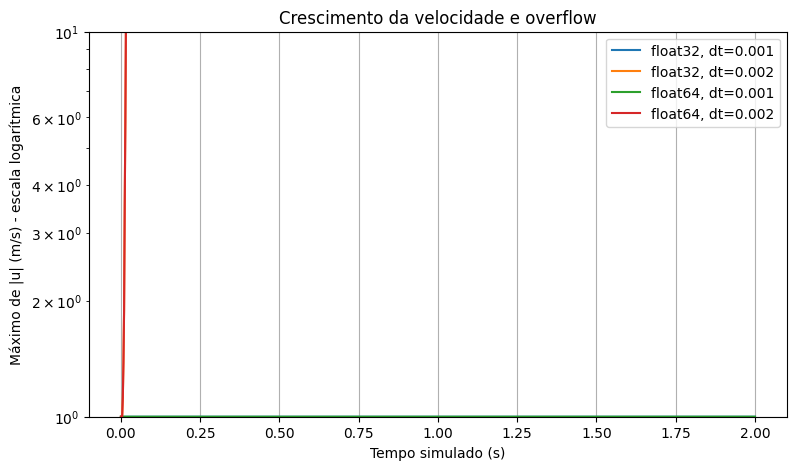


--- Análise dos resultados ---

float32, dt=0.001
r = 0.4000000059604645
Maior |u| = 1.000000e+00 m/s
Situação: velocidade dentro do limite físico.
Nenhum overflow detectado.

float32, dt=0.002
r = 0.800000011920929
Maior |u| = 1.665934e+38 m/s
Situação: solução fisicamente incorreta (|u| > 1 m/s).
Overflow/operação inválida no passo 121.

float64, dt=0.001
r = 0.4000000000000001
Maior |u| = 1.000000e+00 m/s
Situação: velocidade dentro do limite físico.
Nenhum overflow detectado.

float64, dt=0.002
r = 0.8000000000000002
Maior |u| = 4.743391e+307 m/s
Situação: solução fisicamente incorreta (|u| > 1 m/s).
Overflow/operação inválida no passo 917.


In [3]:
import numpy as np
import matplotlib.pyplot as plt


def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    """Simula difusão de velocidade e detecta falhas."""

    H = 0.01
    nu = 1e-4

    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficientes no tipo numérico escolhido
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    # Fluido parado e placa em y=0 em movimento
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]

    falha = None

    # Transforma avisos numéricos em exceções
    with np.errstate(over="raise", invalid="raise"):

        for passo in range(1, passos + 1):

            try:
                novo = u.copy()

                # Atualiza o interior e preserva as paredes
                novo[1:-1] = (
                    u[1:-1]
                    + r * (
                        u[2:]
                        - dois * u[1:-1]
                        + u[:-2]
                    )
                )

            except FloatingPointError as erro:

                falha = passo

                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )

                break

            u = novo

            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(
            f"dt={dt}, {tipo.__name__}: "
            f"{passos} passos sem overflow."
        )

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }


# Maior valor finito representável
print(
    "Maior float32:",
    np.finfo(np.float32).max
)

print(
    "Maior float64:",
    np.finfo(np.float64).max
)


# Executa as simulações
resultados = {}

for tipo in (np.float32, np.float64):

    for dt in (0.001, 0.002):

        nome = f"{tipo.__name__}, dt={dt}"

        resultados[nome] = simular(
            dt,
            tipo
        )


# Gráfico do crescimento da velocidade máxima
plt.figure(figsize=(9, 5))

for nome, resultado in resultados.items():

    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome
    )

plt.xlabel("Tempo simulado (s)")
plt.ylabel("Máximo de |u| (m/s) - escala logarítmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()

print("\n--- Análise dos resultados ---")

for nome, resultado in resultados.items():

    maior_velocidade = max(resultado["maximos"])

    print(f"\n{nome}")
    print(f"r = {resultado['r']}")
    print(f"Maior |u| = {maior_velocidade:.6e} m/s")

    if maior_velocidade <= 1:
        print("Situação: velocidade dentro do limite físico.")
    else:
        print("Situação: solução fisicamente incorreta (|u| > 1 m/s).")

    if resultado["falha"] is not None:
        print(f"Overflow/operação inválida no passo {resultado['falha']}.")
    else:
        print("Nenhum overflow detectado.")

**6) Atividades propostas**


**1. Verificação da estabilidade:**

  Para 21 pontos e $H = 0,01~m$, o passo espacial é $\Delta y = 0,0005~m$.  O limite de estabilidade é $\Delta t_{max} = \frac{\Delta y^2}{2\nu} = 0,00125~s$.  
  
  * Caso A ($\Delta t = 0,001~s$): Resulta em $r = 0,4$. Como $r \le 0,5$, o   método é estável.  
  * Caso B ($\Delta t = 0,002~s$): Resulta em $r = 0,8$. Como $r > 0,5$, o método é instável, pois o coeficiente central da discretização $(1 - 2r)$ torna-se negativo.

**2. Detecção de overflow:**


In [4]:
import pandas as pd
import numpy as np

dados_tabela = []

for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        resultado = simular(dt, tipo, passos=2000, pontos=21)

        r = resultado["r"]
        teve_falha = "Sim" if resultado["falha"] is not None else "Não"
        iteracao_falha = resultado["falha"] if resultado["falha"] is not None else "-"

        dados_tabela.append({
            "Tipo Numérico": tipo.__name__,
            "Passo de Tempo (Δt) [s]": dt,
            "Valor de r": round(r, 1),
            "Ocorreu Overflow?": teve_falha,
            "Iteração da Falha": iteracao_falha
        })

df_resultados = pd.DataFrame(dados_tabela)

df_estilizado = df_resultados.style.set_properties(**{'text-align': 'center'}).set_table_styles([dict(selector='th', props=[('text-align', 'center')])])

display(df_estilizado)

dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


,Tipo Numérico,Passo de Tempo (Δt) [s],Valor de r,Ocorreu Overflow?,Iteração da Falha
0,float32,0.001000,0.400000,Não,-
1,float32,0.002000,0.800000,Sim,121
2,float64,0.001000,0.400000,Não,-
3,float64,0.002000,0.800000,Sim,917


**3) Interpretação física**

O gráfico da maior velocidade em módulo ao longo do tempo permite observar o comportamento das soluções estável e instável.

Fisicamente, a velocidade deve permanecer no intervalo:

$$
0\leq u(y,t)\leq U
$$

Como $U=1$ m/s:

$$
0\leq u(y,t)\leq1\text{ m/s}
$$

No caso estável, espera-se que a solução evolua de forma gradual em direção ao perfil estacionário.

No caso instável, o valor de $r$ ultrapassa o limite de estabilidade:

$$
r=0,8>\frac{1}{2}
$$

Consequentemente, o coeficiente central da atualização:

$$
1-2r
$$

torna-se negativo.

Isso permite o surgimento de oscilações numéricas que podem crescer a cada iteração. O crescimento da velocidade observado nesse caso **não representa o comportamento físico esperado**, mas sim uma instabilidade causada pelo método numérico.


**4) Capacidade de representação**

Os resultados obtidos com `float32` e `float64` serão comparados para verificar o efeito da precisão numérica sobre a falha.

O `float32` possui uma faixa de representação menor que o `float64`:

| Tipo | Maior valor finito aproximado |
|---|---:|
| `float32` | $3,4\times10^{38}$ |
| `float64` | $1,8\times10^{308}$ |

Entretanto, alterar o tipo numérico **não elimina a instabilidade**.

A causa da instabilidade é o valor do parâmetro:

$$
r=\frac{\nu\Delta t}{\Delta y^2}
$$

Quando:

$$
r>\frac{1}{2}
$$

o esquema é instável independentemente de utilizar `float32` ou `float64`.

A diferença observada no número de passos até a falha ocorre porque o `float64` consegue representar números muito maiores antes de atingir overflow. Portanto, ele pode prolongar a execução da solução instável, mas **não corrige sua causa**.


**5) Refinamento da malha**

--- Refinamento para 41 pontos ---
dt=0.001, float64: falha no passo 426, t=0.4260 s - overflow encountered in subtract
dt=0.0002, float64: 10000 passos sem overflow.
Diferença máxima (E_inf) em relação ao perfil estacionário: 0.000000 m/s


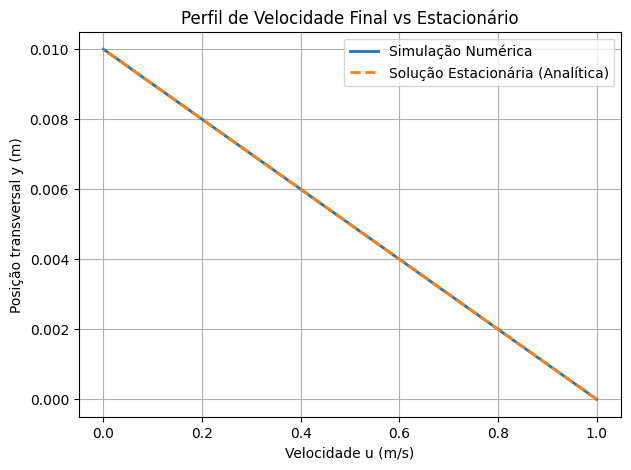

In [5]:
print("--- Refinamento para 41 pontos ---")
resultado_41_instavel = simular(0.001, np.float64, pontos=41)

dt_novo = 0.0002
passos_novo = int(2.0 / dt_novo)
resultado_41_estavel = simular(dt_novo, np.float64, passos=passos_novo, pontos=41)

# Verificação do Perfil de Velocidade
U = 1.0
H = 0.01
y_estavel = resultado_41_estavel["y"]
u_estavel = resultado_41_estavel["u"]

# Solução Estacionária
u_estacionario = U * (1 - y_estavel / H)

# Erro Máximo
E_inf = np.max(np.abs(u_estavel - u_estacionario))
print(f"Diferença máxima (E_inf) em relação ao perfil estacionário: {E_inf:.6f} m/s")

# Plotagem do Perfil
plt.figure(figsize=(7, 5))
plt.plot(u_estavel, y_estavel, label='Simulação Numérica', linewidth=2)
plt.plot(u_estacionario, y_estavel, '--', label='Solução Estacionária (Analítica)', linewidth=2)
plt.ylabel('Posição transversal y (m)')
plt.xlabel('Velocidade u (m/s)')
plt.title('Perfil de Velocidade Final vs Estacionário')
plt.legend()
plt.grid(True)
plt.show()

Ao dobrar o número de pontos (de 21 para 41), o novo espaçamento cai pela metade: $\Delta y = \frac{0,01}{40} = 0,00025~m$.
O limite de estabilidade obedece a uma relação quadrática com a malha ($\Delta t \le \frac{\Delta y^2}{2\nu}$). Portanto, o novo limite é $\Delta t_{max} = \frac{(0,00025)^2}{2 \times 10^{-4}} = 0,0003125~s$.
Executar a simulação com $\Delta t = 0,001~s$ falha porque o novo $r = 1,6$, violando severamente a condição de estabilidade ($r \le 0,5$). Ao baixar o passo para $\Delta t = 0,0002~s$, obtemos $r = 0,32$, recuperando a convergência.

**6) Verificação do perfil de velocidade**

Para uma execução estável e suficientemente longa, será representado graficamente o perfil final de velocidade e realizada a comparação com a solução estacionária:

$$
u_{\mathrm{est}}(y)
=
U\left(1-\frac{y}{H}\right)
$$

Essa expressão representa o **regime estacionário do escoamento**, e não todo o comportamento transiente da solução.

Para quantificar a diferença entre a solução numérica e o perfil estacionário, será calculado o erro em norma do supremo:

$$
E_{\infty}
=
\max_i
\left|
u_i-u_{\mathrm{est}}(y_i)
\right|
$$

Quanto menor for $E_{\infty}$, mais próxima a solução numérica estará do perfil estacionário.

A análise desse erro, juntamente com a comparação gráfica dos dois perfis, permitirá verificar se o tempo de simulação foi suficiente para que o transiente estivesse praticamente concluído e o sistema se aproximasse do regime permanente de difusão de momento, característico do **escoamento de Couette plano**.

> **Importante:** caso o tempo simulado ainda não seja suficientemente longo, uma diferença significativa entre os perfis pode estar relacionada ao transiente ainda não concluído, e não necessariamente a um erro do método numérico.

**7) Conclusão**

Os resultados evidenciam um forte acoplamento entre a discretização espacial e temporal em métodos explícitos. Ao refinar a malha espacial, diminuindo $\Delta y$, é necessário reduzir o passo de tempo $\Delta t$ de forma quadrática para preservar a condição de estabilidade.

Essa relação é determinada pelo número de Fourier da malha:

$$
r=\frac{\nu\Delta t}{\Delta y^2}
$$

Para o esquema utilizado, é necessário garantir:

$$
r\leq\frac{1}{2}
$$

Quando essa condição é violada, o coeficiente central da equação de atualização,

$$
1-2r,
$$

torna-se negativo, favorecendo o surgimento e o crescimento de oscilações não físicas.

Os resultados também mostram que o **overflow não é a causa da falha numérica, mas uma consequência de uma instabilidade preexistente**. O aumento da capacidade de representação, ao utilizar `float64` em vez de `float32`, pode apenas retardar o aparecimento do overflow, sem eliminar a instabilidade.

Portanto, a correção efetiva do problema não está na troca do tipo numérico, mas no **controle do passo de tempo em função do refinamento da malha**, respeitando a restrição:

$$
\boxed{r\leq\frac{1}{2}}
$$

Assim, para o método explícito utilizado nesta atividade, a estabilidade numérica deve ser garantida antes mesmo da preocupação com o overflow.